Sample period: 2.0 ms  (500 Hz)

Discrete plant (ZOH, dt=2.0ms):
  Ad =
[[1.00019621 0.00200013]
 [0.19621283 1.00019621]]
  Bd = [-1.60005232e-03 -1.60010464e+00]
  Open-loop eigenvalue magnitudes: [1.02000659 0.98038582]  (>1 = unstable, correct)

Discrete LQR:
  Kd = [[-3.40356501 -0.60593899]]
  Closed-loop eigenvalue magnitudes: [0.98910545 0.0362753 ]  (<1 = stable)
  Equivalent continuous poles: [   -5.47716739 -1658.30916093]

Luenberger Observer:
  Observer poles (z-domain): [0.92311635 0.88692044]
  Ld = [0.19035563 4.56156757]

FIRMWARE-READY CONSTANTS  —  copy into C
const float Kd[2]    = {-3.403565f, -0.605939f};
const float Ad[2][2] = {{{1.000196f, 0.002000f}, {0.196213f, 1.000196f}}};
const float Bd[2]    = {-0.001600f, -1.600105f};
const float Ld[2]    = {0.190356f, 4.561568f};
const float dt       = 0.0020f;  // 500 Hz


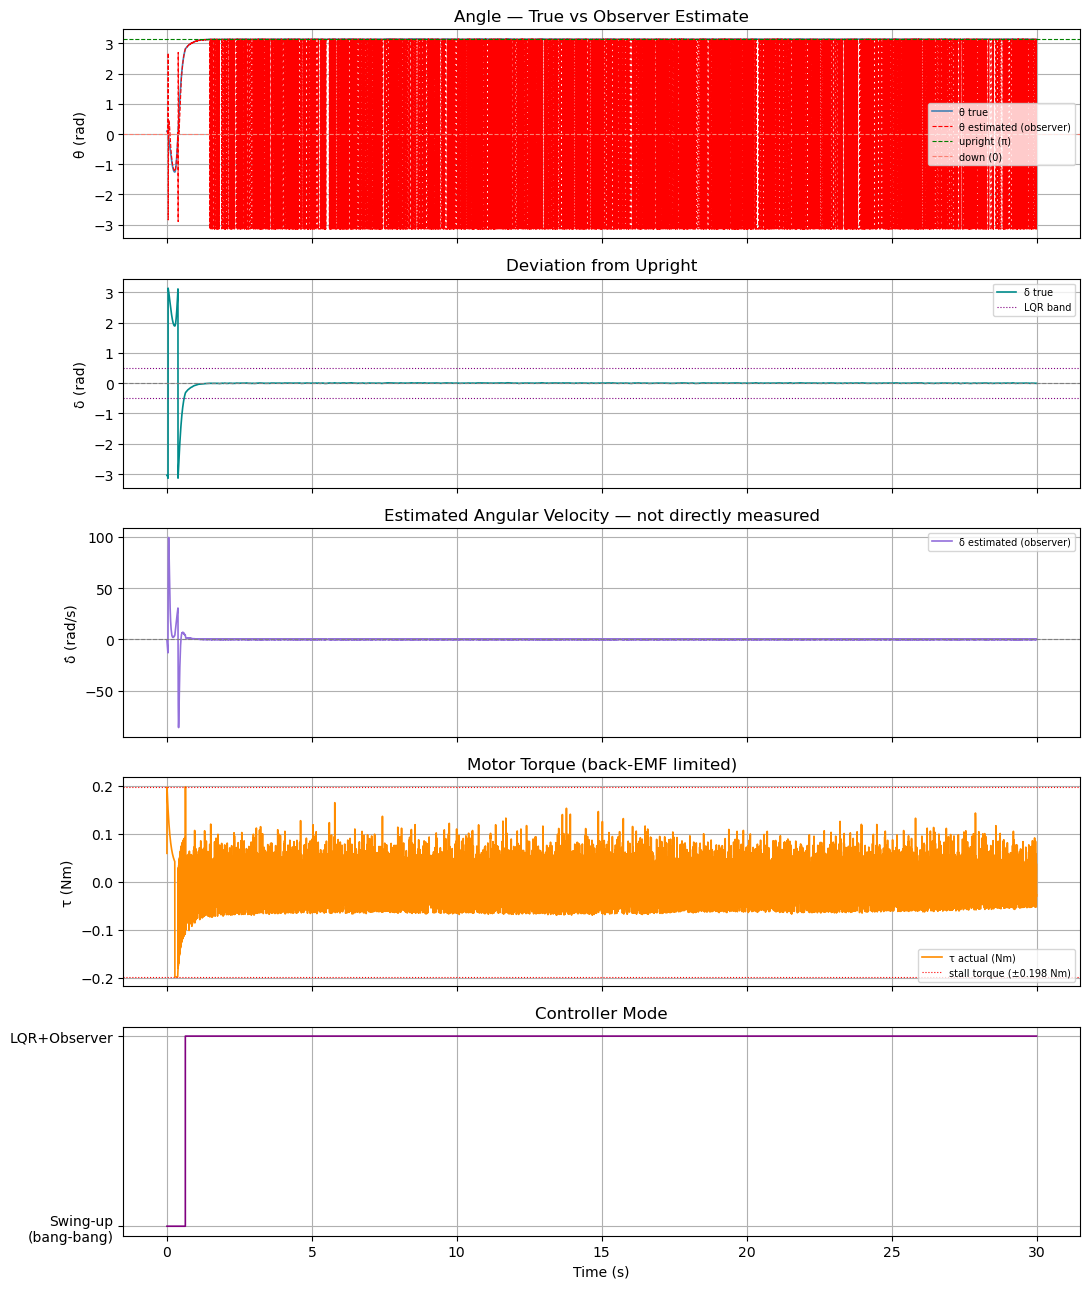


--- Final State ---
theta true:      3.1344 rad  (target π = 3.1416)
theta estimated: 3.1369 rad
delta true:      -0.0072 rad  (target 0)
Max |torque|:    0.1982 Nm  (stall: 0.1982 Nm)
LQR mode:        97.9% of simulation
Observer error at end: 0.0024 rad


In [3]:
"""
REACTION-WHEEL INVERTED PENDULUM — v12
Theodore Price-Parsons
"""

import warnings
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig
import control

warnings.filterwarnings("ignore", category=DeprecationWarning)


# Physical Parameters

m        = 0.25
l        = 0.1
Iw       = 0.0003
g        = 9.81
b        = 0.01



# Pololu #4842 — 9.7:1 HP 12V with encoder
# Datasheet stall: 5.0 A, no-load: ~10000 RPM @ 12V
# https://www.pololu.com/product/4842
V_supply  = 12.0
N         = 9.68
R_m       = 12.0 / 5.0                    # = 2.4 Ω
K_t       = 0.3812 / 5.0                  # = 0.0762 N·m/A
K_e       = (12.0 - 0.3*R_m) / (1000 * 2*np.pi/60)  # = 0.1059 V·s/rad
eta       = 0.52
tau_stall = eta * K_t * V_supply / R_m    # = 0.198 Nm# = 0.198 Nm realistic
k_desat = 0


# Sample period

dt = 0.002   # 500 Hz
print(f"Sample period: {dt*1000:.1f} ms  ({1/dt:.0f} Hz)")


# Continuous linearised plant (around upright)

A = np.array([[0,    1  ],
              [g/l,  0  ]])
B = np.array([[0              ],
              [-2 / (m * l**2)]])


# ZOH Discretisation

sysd = sig.StateSpace(A, B, np.eye(2), np.zeros((2,1))).to_discrete(dt, method='zoh')
Ad   = sysd.A
Bd   = sysd.B

print(f"\nDiscrete plant (ZOH, dt={dt*1000:.1f}ms):")
print(f"  Ad =\n{Ad}")
print(f"  Bd = {Bd.flatten()}")
print(f"  Open-loop eigenvalue magnitudes: {np.abs(np.linalg.eigvals(Ad))}  (>1 = unstable, correct)")


# Here we calculate our iscrete LQR

Q  = np.diag([300.0, 10.0])
R  = np.array([[1.0]])
Kd, _, eig_cl = control.dlqr(Ad, Bd, Q, R)
eig_cl_cont   = np.log(eig_cl) / dt

print(f"\nDiscrete LQR:")
print(f"  Kd = {Kd}")
print(f"  Closed-loop eigenvalue magnitudes: {np.abs(eig_cl)}  (<1 = stable)")
print(f"  Equivalent continuous poles: {np.real(eig_cl_cont)}")


# Luenberger Observer

C_obs       = np.array([[1, 0]])
obs_poles_z = np.exp(np.array([-40.0, -60.0]) * dt)
Ld          = control.place(Ad.T, C_obs.T, obs_poles_z).T

print(f"\nLuenberger Observer:")
print(f"  Observer poles (z-domain): {obs_poles_z}")
print(f"  Ld = {Ld.flatten()}")


# Noise and switching
sigma_angle  = 0.02   # rad (~1.1 degrees)
delta_sw     = 0.5    # rad
delta_dot_sw = 4.0    # rad/s
np.random.seed(42)


# Helpers
def wrap(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi

def motor_torque(V_cmd, omega_output):
    V = np.clip(V_cmd, -V_supply, V_supply)
    V_eff = V - K_e * omega_output
    V_eff = np.clip(V_eff, -V_supply, V_supply) 
    return K_t * V_eff / R_m * eta

def derivatives(x, V_cmd):
    """Continuous dynamics. Takes voltage V_cmd, computes torque internally."""
    theta, theta_dot, phi_dot = x
    omega_w = phi_dot
    tau     = motor_torque(V_cmd, omega_w)
    th_dd   = (-(g/l)*np.sin(theta)
               - (b/(m*l**2))*theta_dot
               - (2/(m*l**2))*tau)
    ph_dd   = ((tau/Iw)
               + (g/l)*np.sin(theta)
               + (2/(m*l**2))*tau)
    return np.array([theta_dot, th_dd, ph_dd])


# Initial conditions

theta0    = 0.1
x         = np.array([theta0, 0.0, 0.0])
x_hat     = np.array([wrap(theta0 - np.pi), 0.0])
V_prev    = 0.0   # previous timestep voltage, for observer prediction
omega_prev = 0.0  # previous timestep wheel speed, for observer prediction

t         = 0.0
t_end     = 30.0

# Storage
log_t          = []
log_theta      = []
log_theta_hat  = []
log_ddot_hat   = []
log_delta_true = []
log_tau        = []
log_mode       = []
log_omega      = []


# Discrete simulation loop

while t < t_end:
    theta, theta_dot, phi_dot = x
    omega_wheel = phi_dot

    # --- Observer: prediction step (uses previous V_cmd and omega) ---
    x_hat = Ad @ x_hat + Bd.flatten() * motor_torque(V_prev, omega_prev)

    #Noisy measurement
    theta_meas = theta + np.random.normal(0, sigma_angle)
    delta_meas = wrap(theta_meas - np.pi)

    #Observer: correction step ---
    x_hat = x_hat + Ld.flatten() * (delta_meas - x_hat[0])
    delta_hat = x_hat[0]
    ddot_hat  = x_hat[1]

    # --- Swing-up uses TRUE state ---
    E      = 0.5 * m * l**2 * theta_dot**2 - m * g * l * np.cos(theta)
    E_star = m * g * l
    if abs(theta_dot) < 1e-6:
        V_su = V_supply * 0.3
    elif E < E_star:
        V_su = -V_supply * np.sign(theta_dot)
    else:
        V_su = 0.0

    # --- LQR uses observer estimates ---
    tau_lqr_des = -(Kd @ x_hat).item()
    V_lqr       = (tau_lqr_des / K_t) * R_m + K_e * omega_wheel
    V_lqr += -k_desat * phi_dot

    # Switch
    near  = (abs(delta_hat) < delta_sw and abs(ddot_hat) < delta_dot_sw)
    V_cmd = np.clip(V_lqr if near else V_su, -V_supply, V_supply)

    #RK4 integration
    k1 = derivatives(x, V_cmd)
    k2 = derivatives(x + 0.5*dt*k1, V_cmd)
    k3 = derivatives(x + 0.5*dt*k2, V_cmd)
    k4 = derivatives(x + dt*k3,     V_cmd)
    x  = x + (dt/6)*(k1 + 2*k2 + 2*k3 + k4)

    #Compute actual torque for logging (at current omega, before integration)
    tau_act = motor_torque(V_cmd, omega_wheel)

    #Saving for next prediction
    V_prev = V_cmd
    omega_prev = omega_wheel

    #log
    log_t.append(t)
    log_theta.append(theta)
    log_theta_hat.append(wrap(x_hat[0] + np.pi))
    log_ddot_hat.append(ddot_hat)
    log_delta_true.append(wrap(theta - np.pi))
    log_tau.append(tau_act)
    log_mode.append(1.0 if near else 0.0)
    log_omega.append(omega_wheel)

    t += dt

# Converting logs
(log_t, log_theta, log_theta_hat, log_ddot_hat,
 log_delta_true, log_tau, log_mode, log_omega) = map(np.array, [
    log_t, log_theta, log_theta_hat, log_ddot_hat,
    log_delta_true, log_tau, log_mode, log_omega])


# Firmware constants

print(f"\n{'='*52}")
print("FIRMWARE-READY CONSTANTS  —  copy into C")
print(f"{'='*52}")
print(f"const float Kd[2]    = {{{Kd[0][0]:.6f}f, {Kd[0][1]:.6f}f}};")
print("const float Ad[2][2] = {{" +
      f"{{{Ad[0][0]:.6f}f, {Ad[0][1]:.6f}f}}, " +
      f"{{{Ad[1][0]:.6f}f, {Ad[1][1]:.6f}f}}}}}};")
print(f"const float Bd[2]    = {{{Bd[0][0]:.6f}f, {Bd[1][0]:.6f}f}};")
print(f"const float Ld[2]    = {{{Ld[0][0]:.6f}f, {Ld[1][0]:.6f}f}};")
print(f"const float dt       = {dt:.4f}f;  // 500 Hz")


# Plots
fig, axes = plt.subplots(5, 1, figsize=(11, 13), sharex=True)

axes[0].plot(log_t, log_theta,     color='steelblue', lw=1.2, label='θ true')
axes[0].plot(log_t, log_theta_hat, color='red',       lw=0.8,
             ls='--', label='θ estimated (observer)')
axes[0].axhline(np.pi, color='green',  ls='--', lw=0.8, label='upright (π)')
axes[0].axhline(0,     color='salmon', ls='--', lw=0.8, label='down (0)')
axes[0].set_ylabel("θ (rad)")
axes[0].legend(fontsize=7)
axes[0].grid(True)
axes[0].set_title("Angle — True vs Observer Estimate")

axes[1].plot(log_t, log_delta_true, color='darkcyan', lw=1.2, label='δ true')
axes[1].axhline( delta_sw, color='purple', ls=':', lw=0.8, label='LQR band')
axes[1].axhline(-delta_sw, color='purple', ls=':', lw=0.8)
axes[1].axhline(0,         color='gray',   ls='--', lw=0.8)
axes[1].set_ylabel("δ (rad)")
axes[1].legend(fontsize=7)
axes[1].grid(True)
axes[1].set_title("Deviation from Upright")

axes[2].plot(log_t, log_ddot_hat, color='mediumpurple', lw=1.2,
             label='δ̇ estimated (observer)')
axes[2].axhline(0, color='gray', ls='--', lw=0.8)
axes[2].set_ylabel("δ̇ (rad/s)")
axes[2].legend(fontsize=7)
axes[2].grid(True)
axes[2].set_title("Estimated Angular Velocity — not directly measured")

axes[3].plot(log_t, log_tau, color='darkorange', lw=1.2, label='τ actual (Nm)')
axes[3].axhline( tau_stall, color='red', ls=':', lw=0.8,
                label=f'stall torque (±{tau_stall:.3f} Nm)')
axes[3].axhline(-tau_stall, color='red', ls=':', lw=0.8)
axes[3].set_ylabel("τ (Nm)")
axes[3].legend(fontsize=7)
axes[3].grid(True)
axes[3].set_title("Motor Torque (back-EMF limited)")

axes[4].plot(log_t, log_mode, color='purple', drawstyle='steps-post', lw=1.2)
axes[4].set_yticks([0, 1])
axes[4].set_yticklabels(['Swing-up\n(bang-bang)', 'LQR+Observer'])
axes[4].set_xlabel("Time (s)")
axes[4].grid(True)
axes[4].set_title("Controller Mode")

plt.tight_layout()
plt.savefig("pendulum_v9.png", dpi=150)
plt.show()


# Terminal report
print(f"\n--- Final State ---")
print(f"theta true:      {log_theta[-1]:.4f} rad  (target π = {np.pi:.4f})")
print(f"theta estimated: {log_theta_hat[-1]:.4f} rad")
print(f"delta true:      {log_delta_true[-1]:.4f} rad  (target 0)")
print(f"Max |torque|:    {np.max(np.abs(log_tau)):.4f} Nm  (stall: {tau_stall:.4f} Nm)")
print(f"LQR mode:        {np.sum(log_mode)/len(log_mode)*100:.1f}% of simulation")
print(f"Observer error at end: {abs(log_theta[-1] - log_theta_hat[-1]):.4f} rad")

In [2]:
pip install control

  Using cached control-0.10.2-py3-none-any.whl.metadata (7.6 kB)
Using cached control-0.10.2-py3-none-any.whl (578 kB)

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
